# Offline Automatic Speech Recognition: A Systematic Benchmark

This notebook provides a reproducible comparative evaluation of offline automatic
speech recognition (ASR) systems with respect to transcription accuracy and
inference speed.  All systems operate entirely without network connectivity;
cloud-based services are outside the scope of this study.

## Systems under evaluation

| # | System | Backend | Notes |
|---|--------|---------|-------|
| 1 | Faster-Whisper tiny | CTranslate2 | Smallest parameter count |
| 2 | Faster-Whisper base | CTranslate2 | Balanced model |
| 3 | Faster-Whisper small | CTranslate2 | Moderate accuracy |
| 4 | Faster-Whisper medium | CTranslate2 | Near-state-of-the-art accuracy |
| 5 | Faster-Whisper large-v3-turbo | CTranslate2 | Distilled large model |
| 6 | Faster-Whisper distil-small.en | CTranslate2 | English-only distilled variant |
| 7 | OpenAI Whisper base | PyTorch | Reference implementation |
| 8 | Vosk small-en-us-0.15 | Kaldi / TDNN | Lightweight offline model |
| 9 | Vosk en-us-0.22-lgraph | Kaldi / TDNN | Large-vocabulary graph model |

## Evaluation metrics

| Metric | Definition | Preferred direction |
|--------|------------|---------------------|
| **WER** | Word Error Rate: `(S + D + I) / N` where S = substitutions, D = deletions, I = insertions, N = reference word count | Lower |
| **CER** | Character Error Rate: analogous to WER at the character level | Lower |
| **RTF** | Real-Time Factor: `transcription_time / audio_duration` | Lower |

All text comparisons are performed after normalisation (Unicode NFKD
decomposition, lowercasing, punctuation removal, whitespace collapsing) to
ensure that surface-level formatting differences do not distort error rates.

## Reference material

The benchmark corpus consists of the opening prologue of *Romeo and Juliet*
(Shakespeare) as recorded in the LibriVox public-domain audiobook:
<https://archive.org/details/romeoandjuliet_ss_0901_librivox>


## 0. Dependency Installation

In [1]:
# Run once to install all required packages.
# The `uv` package manager is assumed; substitute `pip install` if unavailable.
!uv add faster-whisper openai-whisper vosk jiwer librosa soundfile matplotlib pandas numpy requests


Resolved 189 packages in 0.93ms
Checked 167 packages in 3ms


## 1. Imports and Global Configuration

In [2]:
import json
import re
import sys
import tempfile
import time
import unicodedata
import warnings
import wave
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import librosa
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import soundfile as sf
from jiwer import cer, wer

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Colour palette for visualisations
# ---------------------------------------------------------------------------
PALETTE: list[str] = [
    "#4F46E5",  # indigo
    "#7C3AED",  # violet
    "#A855F7",  # purple
    "#EC4899",  # pink
    "#F97316",  # orange
    "#10B981",  # emerald
    "#06B6D4",  # cyan
    "#EF4444",  # red
    "#84CC16",  # lime
]

BG: str      = "#0F0F1A"
BG_CARD: str = "#16162A"
FG: str      = "#E2E8F0"
GRID: str    = "#2D2D4A"

plt.rcParams.update(
    {
        "figure.facecolor": BG,
        "axes.facecolor":   BG_CARD,
        "axes.edgecolor":   GRID,
        "axes.labelcolor":  FG,
        "axes.titlecolor":  FG,
        "xtick.color":      FG,
        "ytick.color":      FG,
        "text.color":       FG,
        "grid.color":       GRID,
        "grid.linestyle":   "--",
        "grid.linewidth":   0.6,
        "font.family":      "sans-serif",
        "font.size":        11,
        "legend.facecolor": BG_CARD,
        "legend.edgecolor": GRID,
    }
)

print("Imports complete.")


Imports complete.


## 2. Experimental Configuration

Edit the constants in the cell below before executing subsequent cells.

**Option A** — Supply a path to an existing audio file (WAV, MP3, or FLAC)
together with a corresponding plain-text reference transcript.

**Option B** — Leave `AUDIO_PATH = None` to generate a synthetic test signal
via gTTS (requires network access on first use) or pyttsx3 (fully offline
fallback).


In [3]:
# ---------------------------------------------------------------------------
# User configuration — modify as required
# ---------------------------------------------------------------------------

# Path to the audio file under evaluation (WAV, MP3, or FLAC).
# Set to None to generate a synthetic audio file.
AUDIO_PATH: Optional[str] = "/media/eduardo/TOSHIBA/data/romeo_and_juliet_audiobook_fragment.mp3"

# Path to a UTF-8 plain-text file containing the verbatim reference transcript.
# Required for metric computation when AUDIO_PATH is provided.
REFERENCE_TEXT_PATH: Optional[str] = "/media/eduardo/TOSHIBA/data/audio_contents.txt"

# Number of timed repetitions per system.  Values greater than one yield more
# stable RTF estimates at the cost of additional wall-clock time.
N_RUNS: int = 1

# Compute precision for Faster-Whisper.  "int8" is recommended for CPU inference.
COMPUTE_TYPE: str = "int8"  # "int8" | "float16" | "float32"

# Inference device for Faster-Whisper and OpenAI Whisper.
DEVICE: str = "cpu"  # "cpu" | "cuda"

# ---------------------------------------------------------------------------
# Synthetic audio parameters — used only when AUDIO_PATH is None
# ---------------------------------------------------------------------------
SYNTH_TEXT: str = (
    "The quick brown fox jumps over the lazy dog. "
    "Speech recognition technology has advanced remarkably in recent years. "
    "Deep learning models now achieve near-human accuracy on many benchmarks. "
    "However, speed and resource consumption remain important practical constraints."
)

print("Configuration loaded.")


Configuration loaded.


## 3. Audio Preparation

In [4]:
WORK_DIR: Path = Path(tempfile.mkdtemp(prefix="asr_bench_"))
WAV_PATH: Path = WORK_DIR / "input.wav"

if AUDIO_PATH is not None:
    source_path = Path(AUDIO_PATH)
    if not source_path.exists():
        raise FileNotFoundError(
            f"Audio file not found: {source_path}\n"
            "Verify that AUDIO_PATH points to an existing WAV, MP3, or FLAC file, "
            "or set AUDIO_PATH = None to use synthetic audio."
        )
    # Resample to 16 kHz mono PCM-16, the format accepted by all evaluated systems.
    audio_array, _ = librosa.load(str(source_path), sr=16_000, mono=True)
    sf.write(str(WAV_PATH), audio_array, 16_000, subtype="PCM_16")

    if REFERENCE_TEXT_PATH is not None:
        ref_path = Path(REFERENCE_TEXT_PATH)
        if not ref_path.exists():
            raise FileNotFoundError(
                f"Reference transcript not found: {ref_path}\n"
                "Verify that REFERENCE_TEXT_PATH points to an existing .txt file."
            )
        reference: str = ref_path.read_text(encoding="utf-8").strip()
    else:
        reference = ""
        print(
            "WARNING: REFERENCE_TEXT_PATH is not set. "
            "WER and CER cannot be computed."
        )
    print(f"Audio loaded from: {WAV_PATH}")

else:
    reference = SYNTH_TEXT
    mp3_path = WORK_DIR / "synth.mp3"
    try:
        from gtts import gTTS  

        gTTS(text=SYNTH_TEXT, lang="en", slow=False).save(str(mp3_path))
        audio_array, _ = librosa.load(str(mp3_path), sr=16_000, mono=True)
        sf.write(str(WAV_PATH), audio_array, 16_000, subtype="PCM_16")
        print("Synthetic audio generated via gTTS.")
    except Exception:
        try:
            import subprocess
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q", "pyttsx3"]
            )
            import pyttsx3  

            engine = pyttsx3.init()
            engine.save_to_file(SYNTH_TEXT, str(WAV_PATH))
            engine.runAndWait()
            print("Synthetic audio generated via pyttsx3 (offline fallback).")
        except Exception as exc:
            raise RuntimeError(
                "Synthetic audio generation failed.  Install gTTS or pyttsx3, "
                "or set AUDIO_PATH to an existing file."
            ) from exc

audio_data, audio_sr = librosa.load(str(WAV_PATH), sr=None, mono=True)
AUDIO_DURATION: float = len(audio_data) / audio_sr

print(f"Duration    : {AUDIO_DURATION:.2f} s  |  Sample rate: {audio_sr} Hz")
print(f"Reference   : {reference[:100]}...")


Audio loaded from: /tmp/asr_bench_465755t3/input.wav
Duration    : 48.04 s  |  Sample rate: 16000 Hz
Reference   : Two households, both alike in dignity, in fair Verona, where we lay our scene, from ancient grudge b...


## 4. Benchmark Infrastructure

In [5]:
@dataclass
class BenchResult:
    """Container for a single system's benchmark measurements."""

    name: str
    transcript: str = ""
    elapsed_s: float = 0.0
    rtf: float = 0.0
    wer_score: float = 1.0
    cer_score: float = 1.0
    error: str = ""
    color: str = "#888888"


def normalise(text: str) -> str:
    """
    Normalise a transcript string for metric computation.

    The following transformations are applied in sequence:

    1. Unicode NFKD decomposition followed by ASCII-only re-encoding to
       remove accents and non-ASCII codepoints.
    2. Lowercasing.
    3. Removal of all non-alphanumeric, non-whitespace characters so that
       punctuation convention differences do not penalise otherwise correct
       transcriptions.
    4. Collapsing of consecutive whitespace to a single space.

    The same function is applied to both the reference and hypothesis strings
    prior to any metric computation.
    """
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode()
    text = re.sub(r"[^\w\s]", "", text.lower())
    return re.sub(r"\s+", " ", text).strip()


def compute_metrics(result: BenchResult, reference: str, duration: float) -> BenchResult:
    """
    Populate WER, CER, and RTF on *result* in-place and return it.

    Both the reference and hypothesis are passed through `normalise` before
    error-rate computation.  WER and CER are clamped to [0, 1] to prevent
    values greater than one from distorting summary statistics in degenerate
    cases (e.g., a hypothesis that is substantially longer than the reference).
    """
    result.rtf = result.elapsed_s / duration if duration > 0 else 0.0

    if reference and result.transcript:
        ref_norm = normalise(reference)
        hyp_norm = normalise(result.transcript)
        result.wer_score = min(1.0, wer(ref_norm, hyp_norm))
        result.cer_score = min(1.0, cer(ref_norm, hyp_norm))

    return result


results: list[BenchResult] = []
print("Benchmark infrastructure initialised.")


Benchmark infrastructure initialised.


## 5. Systems 1–6: Faster-Whisper Family

Faster-Whisper is a re-implementation of OpenAI Whisper using CTranslate2,
a C++ inference engine that supports quantised models and yields substantially
lower memory consumption and latency compared with the reference PyTorch
implementation.  Six model checkpoints are evaluated, spanning the full
accuracy–speed spectrum.


In [6]:
from faster_whisper import WhisperModel

FASTER_WHISPER_MODELS: list[tuple[str, str]] = [
    ("Faster-Whisper tiny",              "tiny"),
    ("Faster-Whisper base",              "base"),
    ("Faster-Whisper small",             "small"),
    ("Faster-Whisper medium",            "medium"),
    ("Faster-Whisper large-v3-turbo",    "large-v3-turbo"),
    ("Faster-Whisper distil-small.en",   "distil-small.en"),
]

for idx, (label, model_id) in enumerate(FASTER_WHISPER_MODELS):
    print(f"Evaluating {label} ...", end=" ", flush=True)
    result = BenchResult(name=label, color=PALETTE[idx % len(PALETTE)])
    try:
        model = WhisperModel(model_id, device=DEVICE, compute_type=COMPUTE_TYPE)
        t0 = time.perf_counter()
        for _ in range(N_RUNS):
            segments, _ = model.transcribe(str(WAV_PATH), beam_size=5)
            result.transcript = " ".join(seg.text.strip() for seg in segments)
        result.elapsed_s = (time.perf_counter() - t0) / N_RUNS
        del model
    except Exception as exc:
        result.error = str(exc)
        print(f"ERROR — {exc}")
    compute_metrics(result, reference, AUDIO_DURATION)
    results.append(result)
    print(
        f"RTF={result.rtf:.3f}  WER={result.wer_score:.3f}  "
        f"Transcript excerpt: {result.transcript[:60]}..."
    )


Evaluating Faster-Whisper tiny ... RTF=0.203  WER=0.151  Transcript excerpt: Two households, both alike and dignity, and fair verona wher...
Evaluating Faster-Whisper base ... RTF=0.297  WER=0.085  Transcript excerpt: Two households, both alike in dignity and fair verona where ...
Evaluating Faster-Whisper small ... RTF=0.868  WER=0.047  Transcript excerpt: Two households, both alike in dignity, in fair Verona where ...
Evaluating Faster-Whisper medium ... RTF=2.547  WER=0.113  Transcript excerpt: In fair Verona where we lay our scene, From ancient grudge b...
Evaluating Faster-Whisper large-v3-turbo ... RTF=2.234  WER=0.028  Transcript excerpt: two households both alike in dignity in fair verona where we...
Evaluating Faster-Whisper distil-small.en ... RTF=1.367  WER=0.434  Transcript excerpt: Two households, both alike in dignity, and fair Verona, wher...


## 6. System 7: OpenAI Whisper (base, PyTorch reference implementation)

The reference implementation provided by OpenAI serves as a baseline against
which the optimised CTranslate2 backend can be directly compared at equivalent
model size.


In [7]:
import whisper as oai_whisper

label = "OpenAI Whisper base"
print(f"Evaluating {label} ...", end=" ", flush=True)
result = BenchResult(name=label, color=PALETTE[6])
try:
    model = oai_whisper.load_model("base")
    t0 = time.perf_counter()
    for _ in range(N_RUNS):
        output = model.transcribe(str(WAV_PATH))
        result.transcript = output["text"].strip()
    result.elapsed_s = (time.perf_counter() - t0) / N_RUNS
    del model
except Exception as exc:
    result.error = str(exc)
    print(f"ERROR — {exc}")
compute_metrics(result, reference, AUDIO_DURATION)
results.append(result)
print(
    f"RTF={result.rtf:.3f}  WER={result.wer_score:.3f}  "
    f"Transcript excerpt: {result.transcript[:60]}..."
)


Evaluating OpenAI Whisper base ... RTF=0.588  WER=0.075  Transcript excerpt: Two households, both alike in dignity, and fair verona where...


## 7. Systems 8–9: Vosk (Kaldi-based offline models)

Vosk is a speech recognition toolkit based on the Kaldi framework.  Unlike the
Whisper family, Vosk employs classical TDNN acoustic models combined with
finite-state-transducer (FST) decoding graphs, making it well-suited for
resource-constrained deployments.  Two English model checkpoints are evaluated:

- **vosk-model-small-en-us-0.15** — a compact model (~50 MB) intended for
  embedded and edge applications.
- **vosk-model-en-us-0.22-lgraph** — a larger model (~128 MB) with an extended
  lexical graph, providing superior coverage of out-of-vocabulary terms.

Both models are downloaded automatically on first execution and cached in the
working directory.


In [8]:
from vosk import KaldiRecognizer, Model as VoskModel, SetLogLevel  

SetLogLevel(-1)  # Suppress Vosk diagnostic output.


def _download_vosk_model(model_dir: Path, url: str) -> None:
    """Download and extract a Vosk model archive if not already present."""
    if model_dir.exists():
        print(f"  Model found at {model_dir}; skipping download.")
        return
    print(f"  Downloading {url} ...")
    zip_path = model_dir.parent / (model_dir.name + ".zip")
    with requests.get(url, stream=True, timeout=120) as response:
        response.raise_for_status()
        with open(zip_path, "wb") as fh:
            for chunk in response.iter_content(chunk_size=8192):
                fh.write(chunk)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(model_dir.parent)
    zip_path.unlink()
    print(f"  Extracted to {model_dir}.")


def _run_vosk(
    model_dir: Path,
    wav_path: Path,
    n_runs: int,
) -> tuple[str, float]:
    """
    Transcribe *wav_path* with the Vosk model located at *model_dir*.

    Returns the transcript string and the mean elapsed time in seconds.
    """
    vosk_model = VoskModel(str(model_dir))
    transcript = ""
    t0 = time.perf_counter()
    for _ in range(n_runs):
        with wave.open(str(wav_path), "rb") as wf:
            recogniser = KaldiRecognizer(vosk_model, wf.getframerate())
            recogniser.SetWords(False)
            fragments: list[str] = []
            while True:
                data = wf.readframes(4000)
                if not data:
                    break
                if recogniser.AcceptWaveform(data):
                    chunk = json.loads(recogniser.Result())
                    fragments.append(chunk.get("text", ""))
            final = json.loads(recogniser.FinalResult())
            fragments.append(final.get("text", ""))
        transcript = " ".join(fragment for fragment in fragments if fragment)
    elapsed = (time.perf_counter() - t0) / n_runs
    return transcript, elapsed


VOSK_MODELS: list[tuple[str, str, str]] = [
    (
        "Vosk small-en-us-0.15",
        "vosk-model-small-en-us-0.15",
        "https://alphacephei.com/vosk/models/vosk-model-small-en-us-0.15.zip",
    ),
    (
        "Vosk en-us-0.22-lgraph",
        "vosk-model-en-us-0.22-lgraph",
        "https://alphacephei.com/vosk/models/vosk-model-en-us-0.22-lgraph.zip",
    ),
]

for idx, (label, model_dirname, model_url) in enumerate(VOSK_MODELS):
    print(f"Evaluating {label} ...")
    result = BenchResult(name=label, color=PALETTE[7 + idx])
    model_dir = WORK_DIR / model_dirname
    try:
        _download_vosk_model(model_dir, model_url)
        result.transcript, result.elapsed_s = _run_vosk(model_dir, WAV_PATH, N_RUNS)
    except Exception as exc:
        result.error = str(exc)
        print(f"  ERROR — {exc}")
    compute_metrics(result, reference, AUDIO_DURATION)
    results.append(result)
    print(
        f"  RTF={result.rtf:.3f}  WER={result.wer_score:.3f}  "
        f"Transcript excerpt: {result.transcript[:60]}..."
    )


Evaluating Vosk small-en-us-0.15 ...
  Extracted to /tmp/asr_bench_465755t3/vosk-model-small-en-us-0.15.
  RTF=0.130  WER=0.170  Transcript excerpt: two households both alike and dignity and fair verona where ...
Evaluating Vosk en-us-0.22-lgraph ...
  Extracted to /tmp/asr_bench_465755t3/vosk-model-en-us-0.22-lgraph.
  RTF=0.466  WER=0.104  Transcript excerpt: two households both alike in dignity in fair verona where we...


## 8. Results Summary

In [9]:
records = [
    {
        "System":   r.name,
        "WER":      round(r.wer_score, 4),
        "CER":      round(r.cer_score, 4),
        "RTF":      round(r.rtf, 4),
        "Time (s)": round(r.elapsed_s, 2),
        "Status":   r.error if r.error else "OK",
    }
    for r in results
]

df = pd.DataFrame(records)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", "{:.4f}".format)
print(df.to_string(index=False))


                        System    WER    CER    RTF  Time (s) Status
           Faster-Whisper tiny 0.1509 0.0462 0.2033    9.7700     OK
           Faster-Whisper base 0.0849 0.0297 0.2972   14.2800     OK
          Faster-Whisper small 0.0472 0.0231 0.8680   41.7000     OK
         Faster-Whisper medium 0.1132 0.0825 2.5473  122.3800     OK
 Faster-Whisper large-v3-turbo 0.0283 0.0132 2.2342  107.3400     OK
Faster-Whisper distil-small.en 0.4340 0.3812 1.3672   65.6800     OK
           OpenAI Whisper base 0.0755 0.0264 0.5885   28.2700     OK
         Vosk small-en-us-0.15 0.1698 0.0578 0.1299    6.2400     OK
        Vosk en-us-0.22-lgraph 0.1038 0.0330 0.4661   22.3900     OK


## 9. Visualisations

### 9.1 Plotting Utilities

In [10]:
def bar_chart(
    ax: plt.Axes,
    values: list[float],
    title: str,
    ylabel: str,
    color_list: list[str],
    tick_labels: list[str],
    annotate: bool = True,
) -> None:
    """
    Render a vertical bar chart on *ax*.

    Parameters
    ----------
    ax:
        Matplotlib Axes instance to draw on.
    values:
        Numeric values, one per bar.
    title:
        Chart title.
    ylabel:
        Y-axis label.
    color_list:
        Bar fill colours, one per value.
    tick_labels:
        X-axis tick labels, one per bar.
    annotate:
        If True, annotate each bar with its numeric value.
    """
    x_positions = np.arange(len(values))
    bars = ax.bar(
        x_positions,
        values,
        color=color_list,
        width=0.6,
        edgecolor="#1E1E35",
        linewidth=0.8,
    )
    ax.set_title(title, pad=10, fontsize=13, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(tick_labels, rotation=35, ha="right", fontsize=9)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

    if annotate and values:
        for bar, val in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.015,
                f"{val:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
                color=FG,
            )


print("Plotting utilities ready.")


Plotting utilities ready.


### 9.2 Word Error Rate and Character Error Rate

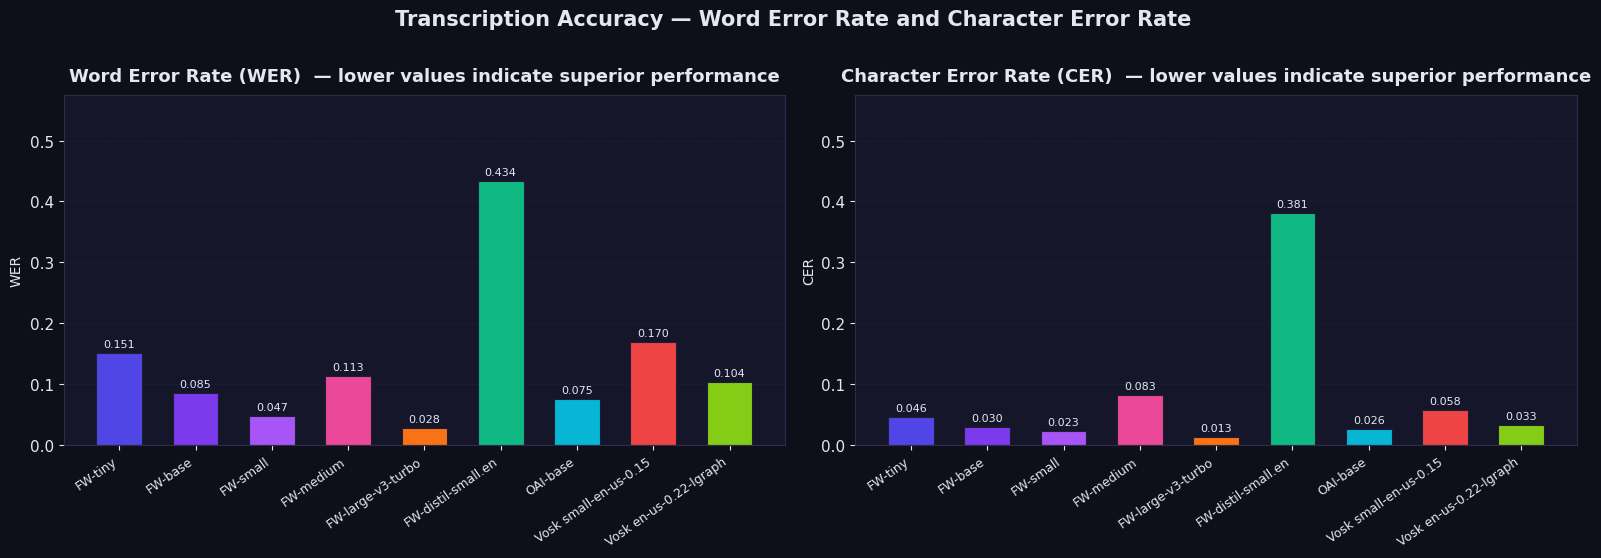

Figure saved: accuracy_wer_cer.png


In [11]:
successful = [r for r in results if not r.error]
names   = [r.name      for r in successful]
colors  = [r.color     for r in successful]
wer_v   = [r.wer_score for r in successful]
cer_v   = [r.cer_score for r in successful]
rtf_v   = [r.rtf       for r in successful]
time_v  = [r.elapsed_s for r in successful]

short_names = [
    n.replace("Faster-Whisper ", "FW-").replace("OpenAI Whisper ", "OAI-")
    for n in names
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor(BG)
fig.suptitle(
    "Transcription Accuracy — Word Error Rate and Character Error Rate",
    fontsize=15,
    fontweight="bold",
    color=FG,
    y=1.01,
)

bar_chart(
    axes[0], wer_v,
    "Word Error Rate (WER)  — lower values indicate superior performance",
    "WER", colors, short_names,
)
bar_chart(
    axes[1], cer_v,
    "Character Error Rate (CER)  — lower values indicate superior performance",
    "CER", colors, short_names,
)

y_max = max(max(wer_v), max(cer_v)) * 1.3 + 0.01
for ax in axes:
    ax.set_ylim(0, y_max)

plt.tight_layout()
plt.savefig("accuracy_wer_cer.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Figure saved: accuracy_wer_cer.png")


### 9.3 Real-Time Factor and Wall-Clock Transcription Time

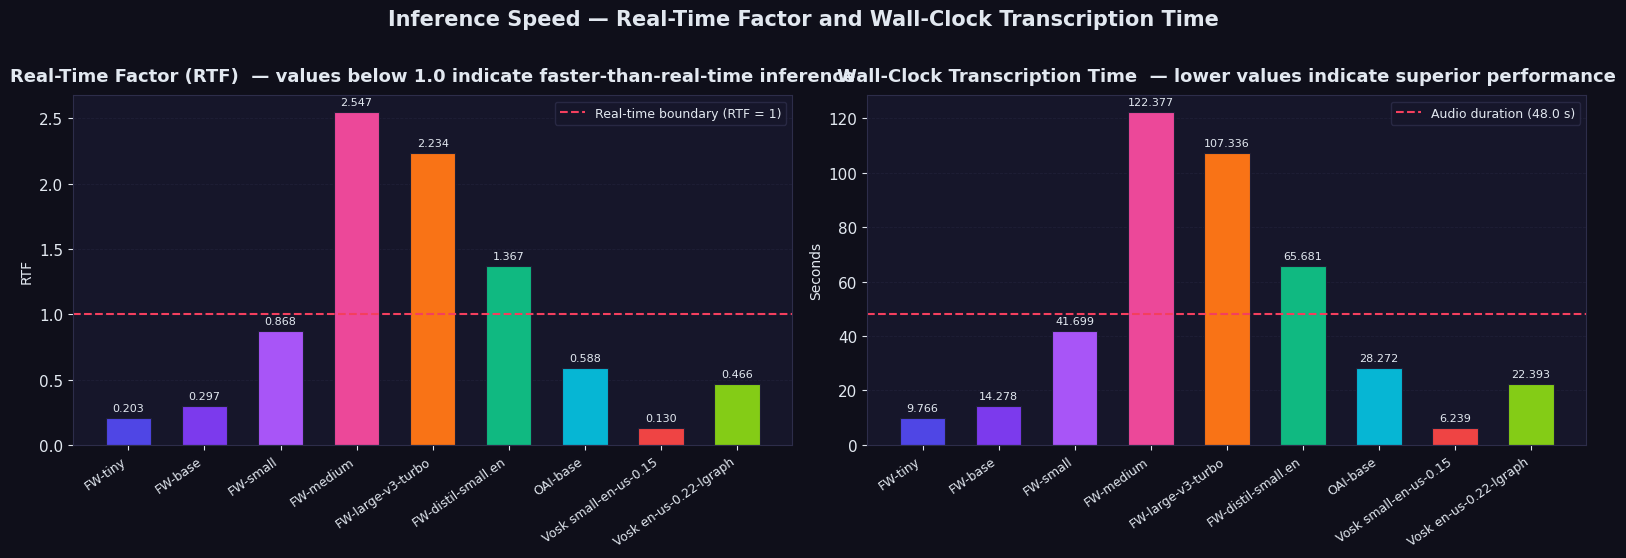

Figure saved: speed_rtf_time.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor(BG)
fig.suptitle(
    "Inference Speed — Real-Time Factor and Wall-Clock Transcription Time",
    fontsize=15,
    fontweight="bold",
    color=FG,
    y=1.01,
)

bar_chart(
    axes[0], rtf_v,
    "Real-Time Factor (RTF)  — values below 1.0 indicate faster-than-real-time inference",
    "RTF", colors, short_names,
)
axes[0].axhline(
    1.0, color="#F43F5E", linewidth=1.5, linestyle="--", label="Real-time boundary (RTF = 1)"
)
axes[0].legend(fontsize=9)

bar_chart(
    axes[1], time_v,
    "Wall-Clock Transcription Time  — lower values indicate superior performance",
    "Seconds", colors, short_names,
)
axes[1].axhline(
    AUDIO_DURATION,
    color="#F43F5E",
    linewidth=1.5,
    linestyle="--",
    label=f"Audio duration ({AUDIO_DURATION:.1f} s)",
)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("speed_rtf_time.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Figure saved: speed_rtf_time.png")


### 9.4 Accuracy–Speed Trade-off Scatter Plot

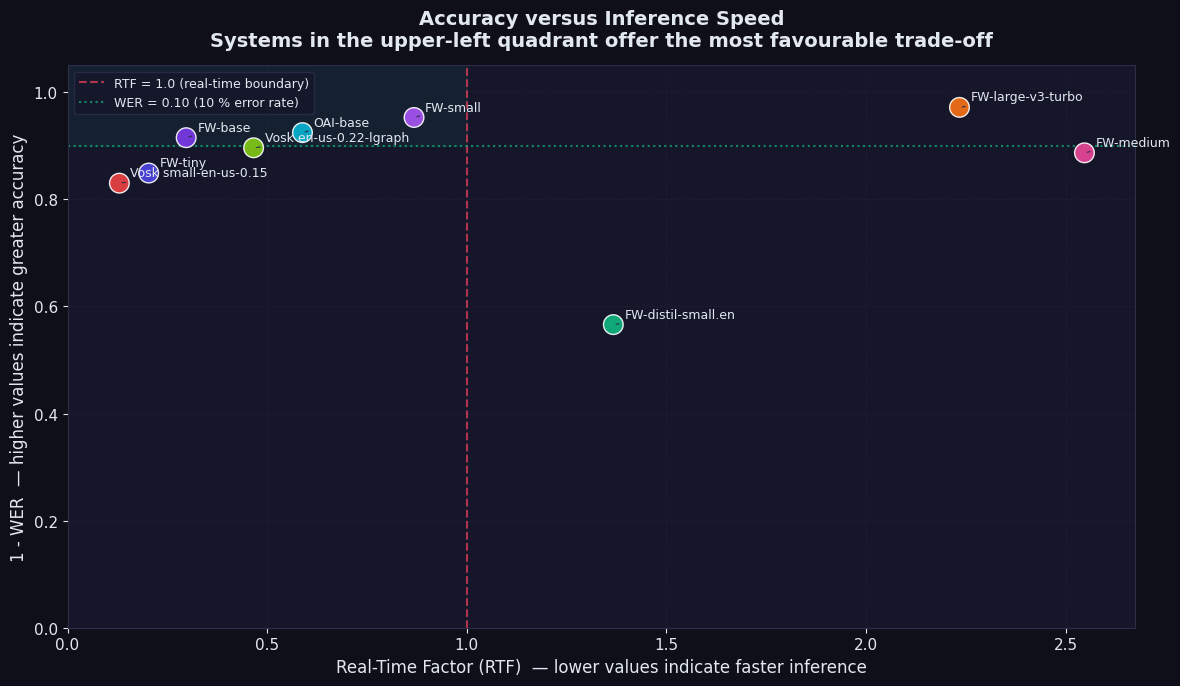

Figure saved: quality_vs_speed.png


In [13]:
# Derive a normalised quality score (1 - WER) solely for positioning on the
# scatter plot Y-axis.  This is not reported as a standalone metric.
quality_v = [1.0 - v for v in wer_v]

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG)

ax.scatter(
    rtf_v,
    quality_v,
    s=200,
    c=colors,
    edgecolors="white",
    linewidths=1.0,
    alpha=0.9,
    zorder=3,
)

for r, x_val, y_val in zip(successful, rtf_v, quality_v):
    label = (
        r.name
        .replace("Faster-Whisper ", "FW-")
        .replace("OpenAI Whisper ", "OAI-")
    )
    ax.annotate(
        label,
        (x_val, y_val),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=9,
        color=FG,
        arrowprops={"arrowstyle": "-", "color": GRID, "lw": 0.8},
    )

ax.axvline(
    1.0,
    color="#F43F5E",
    linewidth=1.5,
    linestyle="--",
    alpha=0.7,
    label="RTF = 1.0 (real-time boundary)",
)
ax.axhline(
    0.90,
    color="#10B981",
    linewidth=1.5,
    linestyle=":",
    alpha=0.7,
    label="WER = 0.10 (10 % error rate)",
)
ax.fill_between(
    [0, 1.0], 0.90, 1.05,
    color="#10B981", alpha=0.07,
)

ax.set_xlim(left=0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Real-Time Factor (RTF)  — lower values indicate faster inference", fontsize=12)
ax.set_ylabel("1 - WER  — higher values indicate greater accuracy", fontsize=12)
ax.set_title(
    "Accuracy versus Inference Speed\n"
    "Systems in the upper-left quadrant offer the most favourable trade-off",
    fontsize=14,
    fontweight="bold",
    pad=14,
)
ax.grid(True, alpha=0.3)
ax.set_axisbelow(True)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("quality_vs_speed.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Figure saved: quality_vs_speed.png")


### 9.5 Composite Dashboard

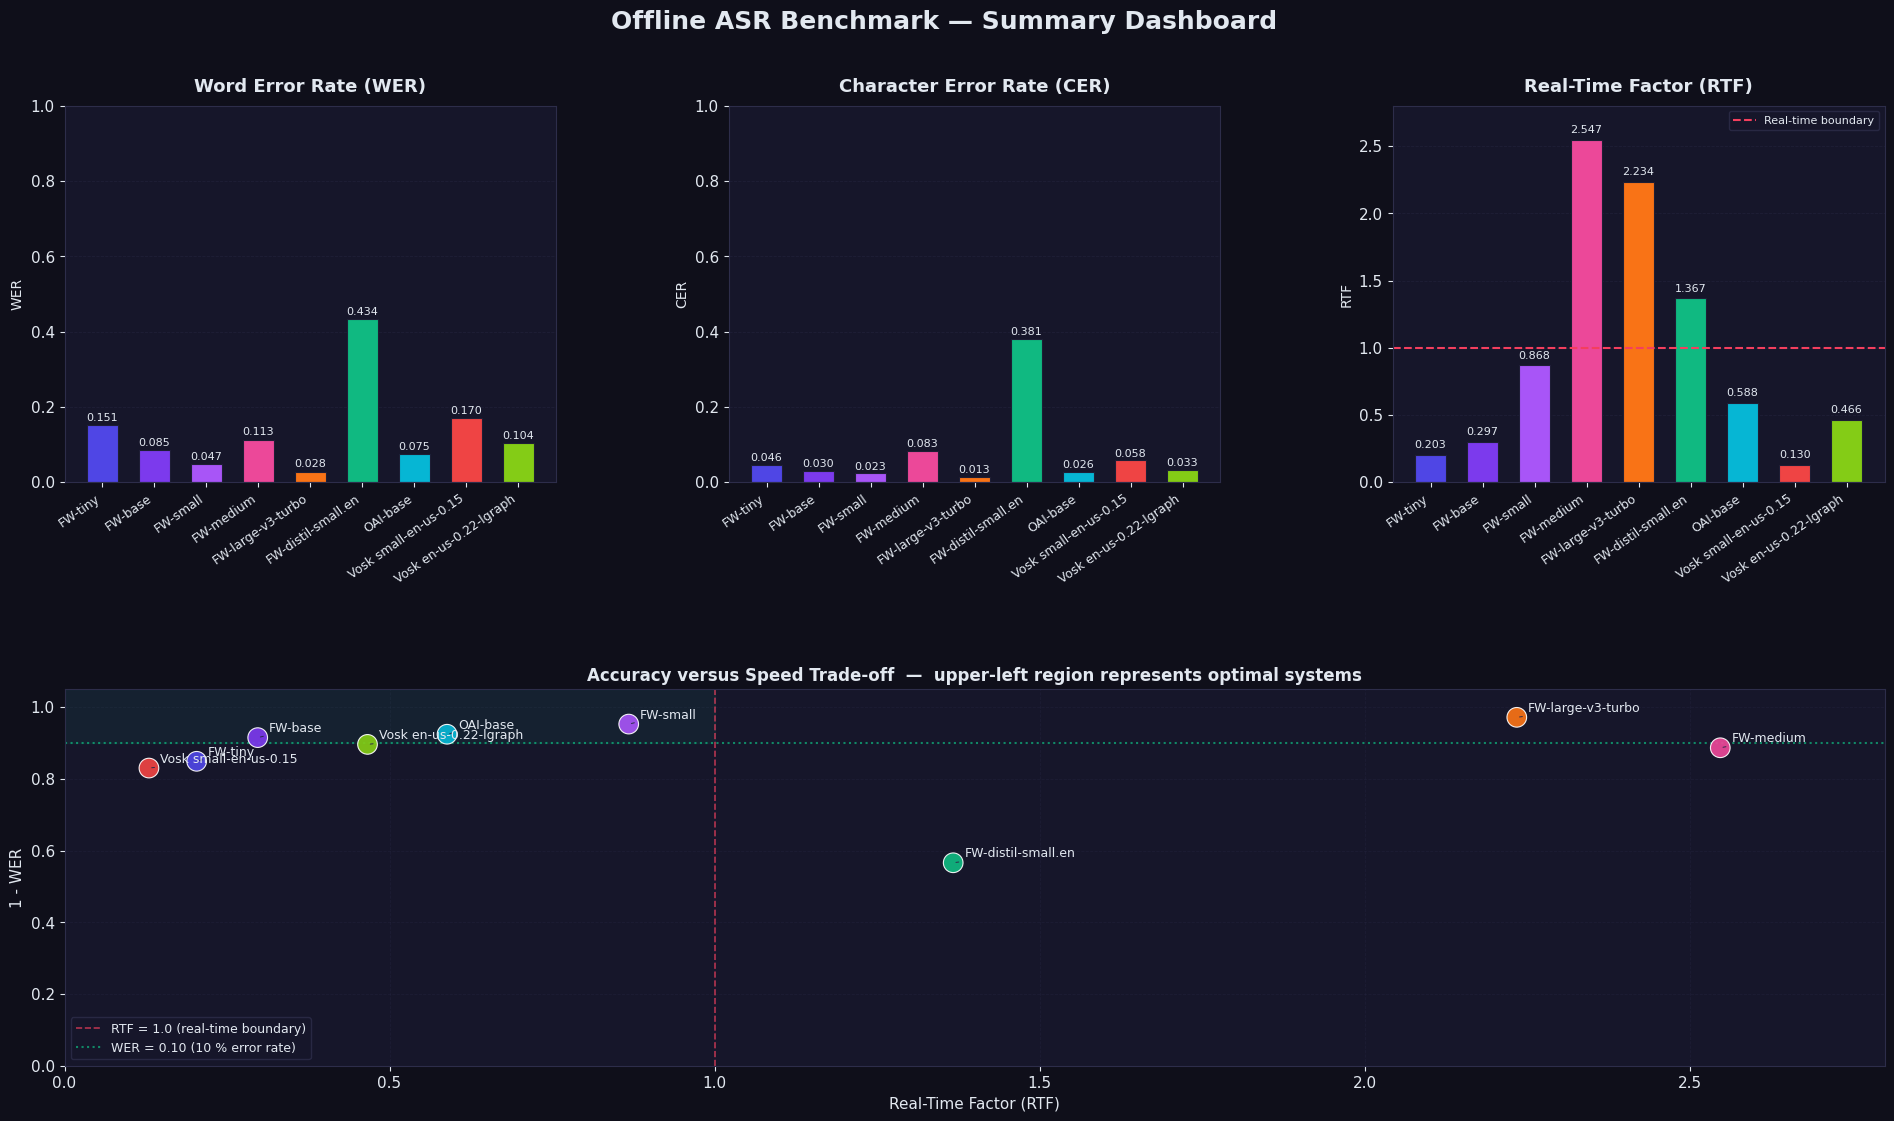

Figure saved: benchmark_dashboard.png


In [19]:
fig = plt.figure(figsize=(20, 12), facecolor=BG)
fig.suptitle(
    "Offline ASR Benchmark — Summary Dashboard",
    fontsize=18,
    fontweight="bold",
    color=FG,
    y=0.98,
)

gs = gridspec.GridSpec(
    2, 3,
    figure=fig,
    hspace=0.55,
    wspace=0.35,
    left=0.06,
    right=0.97,
    top=0.90,
    bottom=0.10,
)

# ---------------------------------------------------------------------------
# Pre-computed Y-axis limits.
# WER and CER are pinned to [0, 1] — their natural range — so that the bar
# heights are directly comparable with the standalone figures and carry an
# unambiguous meaning (0 = no error, 1 = total failure).
# RTF is pinned to [0, 1] so that the real-time boundary line (RTF = 1)
# always sits at the top of the plot area, making it immediately legible
# as a hard constraint rather than an arbitrary annotation inside the bars.
# ---------------------------------------------------------------------------
ERROR_RATE_YLIM = (0, 1.0)
RTF_YLIM = (0, 2.8)

# ---------------------------------------------------------------------------
# Row 0: WER | CER | RTF
# ---------------------------------------------------------------------------
ax_wer = fig.add_subplot(gs[0, 0])
bar_chart(ax_wer, wer_v, "Word Error Rate (WER)", "WER", colors, short_names)
ax_wer.set_ylim(*ERROR_RATE_YLIM)

ax_cer = fig.add_subplot(gs[0, 1])
bar_chart(ax_cer, cer_v, "Character Error Rate (CER)", "CER", colors, short_names)
ax_cer.set_ylim(*ERROR_RATE_YLIM)

ax_rtf = fig.add_subplot(gs[0, 2])
bar_chart(ax_rtf, rtf_v, "Real-Time Factor (RTF)", "RTF", colors, short_names)
ax_rtf.axhline(
    1.0, color="#F43F5E", linewidth=1.5, linestyle="--", label="Real-time boundary"
)
ax_rtf.legend(fontsize=8)
ax_rtf.set_ylim(*RTF_YLIM)

# ---------------------------------------------------------------------------
# Row 1: Accuracy vs Speed scatter (full width)
# ---------------------------------------------------------------------------
ax_scatter = fig.add_subplot(gs[1, :])
ax_scatter.scatter(
    rtf_v, quality_v,
    s=200, c=colors,
    edgecolors="white", linewidths=0.8,
    alpha=0.92, zorder=3,
)
for r, xv, yv in zip(successful, rtf_v, quality_v):
    lbl = r.name.replace("Faster-Whisper ", "FW-").replace("OpenAI Whisper ", "OAI-")
    ax_scatter.annotate(
        lbl, (xv, yv),
        textcoords="offset points", xytext=(8, 4),
        fontsize=9, color=FG,
        arrowprops={"arrowstyle": "-", "color": GRID, "lw": 0.7},
    )

ax_scatter.set_xlim(0, 2.8)
ax_scatter.set_ylim(0, 1.05)

ax_scatter.axvline(
    1.0, color="#F43F5E", linewidth=1.2, linestyle="--",
    label="RTF = 1.0 (real-time boundary)", alpha=0.7,
)
ax_scatter.axhline(
    0.90, color="#10B981", linewidth=1.5, linestyle=":",
    alpha=0.7, label="WER = 0.10 (10 % error rate)",
)
ax_scatter.fill_between(
    [0, 1.0], 0.90, 1.05,
    color="#10B981", alpha=0.07,
)
ax_scatter.set_xlabel("Real-Time Factor (RTF)", fontsize=11)
ax_scatter.set_ylabel("1 - WER", fontsize=11)
ax_scatter.set_title(
    "Accuracy versus Speed Trade-off  —  upper-left region represents optimal systems",
    fontsize=12,
    fontweight="bold",
)
ax_scatter.yaxis.grid(True, alpha=0.3)
ax_scatter.xaxis.grid(True, alpha=0.3)
ax_scatter.set_axisbelow(True)
ax_scatter.legend(fontsize=9)

plt.savefig("benchmark_dashboard.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Figure saved: benchmark_dashboard.png")

## 10. Benchmark Summary

In [15]:
if not successful:
    print("No successful results to summarise.")
else:
    best_wer = min(successful, key=lambda r: r.wer_score)
    best_cer = min(successful, key=lambda r: r.cer_score)
    best_rtf = min(successful, key=lambda r: r.rtf)

    separator = "-" * 72
    print("=" * 72)
    print("BENCHMARK SUMMARY")
    print("=" * 72)
    print(f"  Audio duration       : {AUDIO_DURATION:.2f} s")
    print(
        f"  Systems evaluated    : {len(results)}  "
        f"({len(successful)} completed successfully, "
        f"{len(results) - len(successful)} failed)"
    )
    print()
    print(f"  Lowest WER  : {best_wer.name:<32}  WER={best_wer.wer_score:.4f}")
    print(f"  Lowest CER  : {best_cer.name:<32}  CER={best_cer.cer_score:.4f}")
    print(f"  Lowest RTF  : {best_rtf.name:<32}  RTF={best_rtf.rtf:.4f}")
    print()
    print(separator)
    print(f"  {'System':<34}  {'WER':>7}  {'CER':>7}  {'RTF':>7}  {'Time (s)':>9}")
    print(separator)
    for r in sorted(successful, key=lambda r: r.wer_score):
        markers = ""
        if r is best_wer:
            markers += " [best WER]"
        if r is best_cer:
            markers += " [best CER]"
        if r is best_rtf:
            markers += " [best RTF]"
        print(
            f"  {r.name:<34}  {r.wer_score:>7.4f}  {r.cer_score:>7.4f}"
            f"  {r.rtf:>7.4f}  {r.elapsed_s:>9.2f}{markers}"
        )
    print("=" * 72)


BENCHMARK SUMMARY
  Audio duration       : 48.04 s
  Systems evaluated    : 9  (9 completed successfully, 0 failed)

  Lowest WER  : Faster-Whisper large-v3-turbo     WER=0.0283
  Lowest CER  : Faster-Whisper large-v3-turbo     CER=0.0132
  Lowest RTF  : Vosk small-en-us-0.15             RTF=0.1299

------------------------------------------------------------------------
  System                                  WER      CER      RTF   Time (s)
------------------------------------------------------------------------
  Faster-Whisper large-v3-turbo        0.0283   0.0132   2.2342     107.34 [best WER] [best CER]
  Faster-Whisper small                 0.0472   0.0231   0.8680      41.70
  OpenAI Whisper base                  0.0755   0.0264   0.5885      28.27
  Faster-Whisper base                  0.0849   0.0297   0.2972      14.28
  Vosk en-us-0.22-lgraph               0.1038   0.0330   0.4661      22.39
  Faster-Whisper medium                0.1132   0.0825   2.5473     122.38
  Fast

## 11. Generated Output Files

The following figures are written to the current working directory upon
successful execution of the visualisation cells.

| File | Contents |
|------|----------|
| `accuracy_wer_cer.png` | Side-by-side bar charts of WER and CER for all evaluated systems |
| `speed_rtf_time.png` | Side-by-side bar charts of RTF and wall-clock transcription time |
| `quality_vs_speed.png` | Scatter plot of (1 - WER) versus RTF |
| `benchmark_dashboard.png` | Composite dashboard combining all metric panels |
